In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load the datasets
# -----------------------------
dk = pd.read_csv("Data/time_series_60min_singleindex_filtered_DK.csv")
nl = pd.read_csv("Data/time_series_60min_singleindex_filtered_NL.csv")

# -----------------------------
# 2. Convert timestamps
# -----------------------------
dk["utc_timestamp"] = pd.to_datetime(dk["utc_timestamp"], utc=True)
nl["utc_timestamp"] = pd.to_datetime(nl["utc_timestamp"], utc=True)

dk = dk.set_index("utc_timestamp")
nl = nl.set_index("utc_timestamp")

# Remove timezone for analysis / PyPSA compatibility
dk.index = dk.index.tz_localize(None)
nl.index = nl.index.tz_localize(None)

# -----------------------------
# 3. Basic info
# -----------------------------
print("\n--- Denmark dataset info ---")
print(dk.info())

print("\n--- Netherlands dataset info ---")
print(nl.info())

# -----------------------------
# 4. Missing values check
# -----------------------------
print("\n--- Missing values DK ---")
print(dk.isna().sum())

print("\n--- Missing values NL ---")
print(nl.isna().sum())

# -----------------------------
# 5. Check missing timestamps
# -----------------------------
expected_hours_dk = pd.date_range(dk.index.min(), dk.index.max(), freq="H")
missing_hours_dk = expected_hours_dk.difference(dk.index)

expected_hours_nl = pd.date_range(nl.index.min(), nl.index.max(), freq="H")
missing_hours_nl = expected_hours_nl.difference(nl.index)

print("\nMissing hours DK:", len(missing_hours_dk))
print("Missing hours NL:", len(missing_hours_nl))

# -----------------------------
# 6. Basic statistics
# -----------------------------
print("\n--- DK statistics ---")
print(dk.describe())

print("\n--- NL statistics ---")
print(nl.describe())

# -----------------------------
# 7. Load comparison plot
# -----------------------------
plt.figure(figsize=(12,5))

plt.plot(dk.index, dk["DK_load_actual_entsoe_transparency"], label="Denmark Load")
plt.plot(nl.index, nl["NL_load_actual_entsoe_transparency"], label="Netherlands Load")

plt.title("Electricity Load Comparison")
plt.ylabel("MW")
plt.xlabel("Time")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Capacity factor sanity check
# -----------------------------
dk["solar_cf"] = dk["DK_solar_generation_actual"] / dk["DK_solar_capacity"]
dk["wind_on_cf"] = dk["DK_wind_onshore_generation_actual"] / dk["DK_wind_onshore_capacity"]

print("\nSolar CF range DK:", dk["solar_cf"].min(), dk["solar_cf"].max())
print("Wind CF range DK:", dk["wind_on_cf"].min(), dk["wind_on_cf"].max())

# -----------------------------
# 9. Year coverage
# -----------------------------
print("\nDK time range:", dk.index.min(), "to", dk.index.max())
print("NL time range:", nl.index.min(), "to", nl.index.max())

print("\nTotal rows DK:", len(dk))
print("Total rows NL:", len(nl))


--- Denmark dataset info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 26328 entries, 2014-12-31 23:00:00 to 2018-01-01 22:00:00
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   cet_cest_timestamp                    26328 non-null  str    
 1   DK_load_actual_entsoe_transparency    26326 non-null  float64
 2   DK_load_forecast_entsoe_transparency  26326 non-null  float64
 3   DK_solar_capacity                     26327 non-null  float64
 4   DK_solar_generation_actual            26323 non-null  float64
 5   DK_wind_capacity                      26327 non-null  float64
 6   DK_wind_generation_actual             26326 non-null  float64
 7   DK_wind_offshore_capacity             26327 non-null  float64
 8   DK_wind_offshore_generation_actual    26326 non-null  float64
 9   DK_wind_onshore_capacity              26327 non-null  float64
 10  DK_wind_onshore_generation_a

ValueError: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

C:\Users\user\AppData\Local\Temp\ipykernel_13168\3712418747.py:111: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['DK'], dtype='str', name='name')
Index(['Solar', 'Onshore Wind', 'Offshore Wind', 'Gas'], dtype='str', name='name')


2016-01-01 00:00:00 2016-12-31 23:00:00 8784


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 74.36it/s]
INFO:linopy.io: Writing time: 0.32s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35140 primals, 79060 duals
Objective: 8.92e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.



Optimal capacities (MW):
name
Solar              -0.00
Onshore Wind       -0.00
Offshore Wind      -0.00
Gas              5818.91
Name: p_nom_opt, dtype: float64

Annual generation (MWh):
name
Solar                   0.00
Onshore Wind            0.00
Offshore Wind           0.00
Gas              32296169.25
dtype: float64

Annual electricity mix (%):
name
Solar              0.0
Onshore Wind       0.0
Offshore Wind      0.0
Gas              100.0
dtype: float64

Capacity factors:
name
Solar                 NaN
Onshore Wind          NaN
Offshore Wind         NaN
Gas              0.631854
dtype: float64


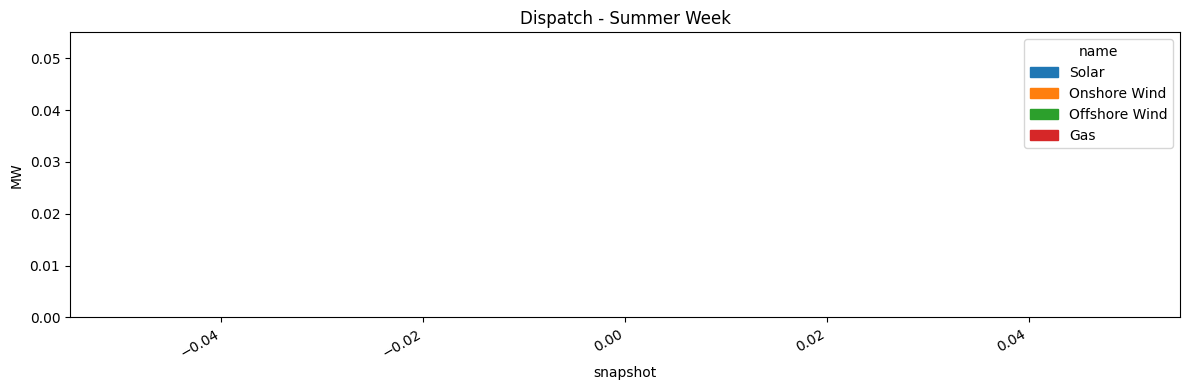

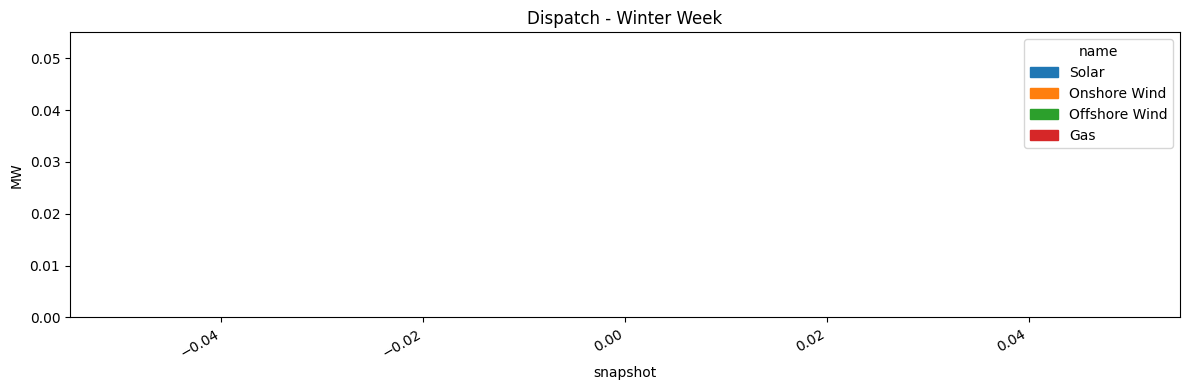

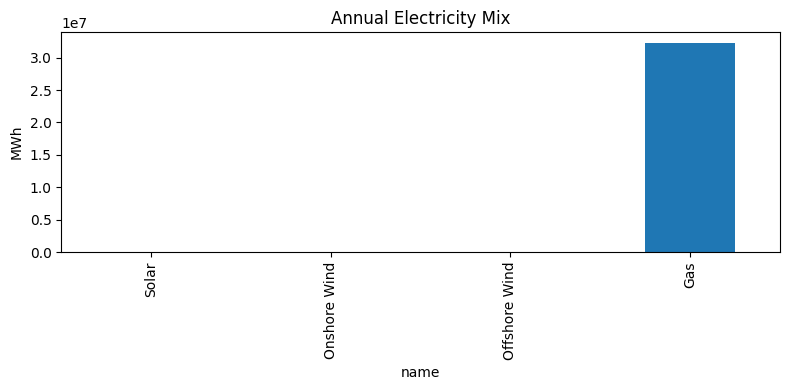

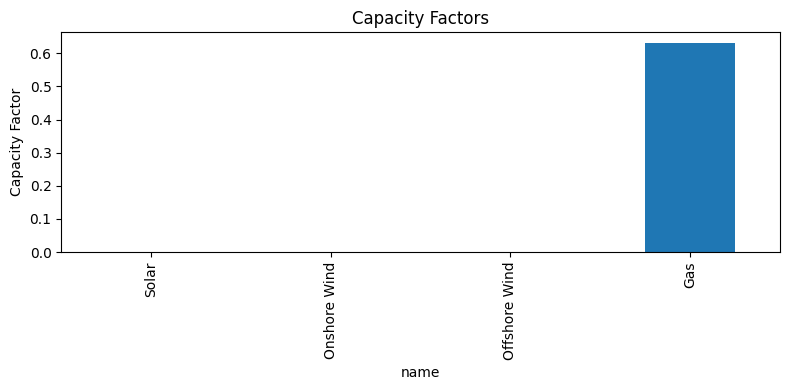

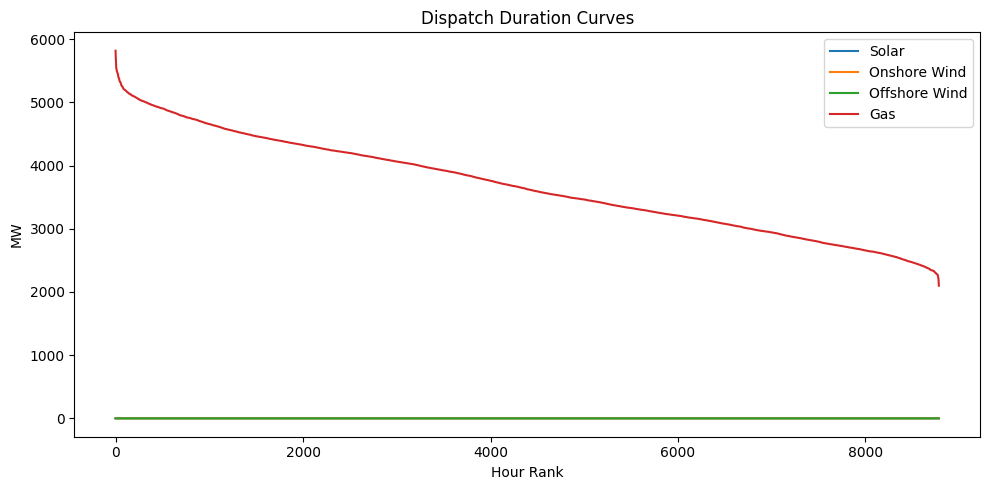

In [23]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read the data
# -----------------------------
df = pd.read_csv("Data/time_series_60min_singleindex_filtered_DK.csv")

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
df = df.set_index("utc_timestamp")
df.index = df.index.tz_localize(None)

# Keep only 2016
df = df.loc["2016-01-01":"2016-12-31"]

# -----------------------------
# 2. Build the time series
# -----------------------------
load_series = df["DK_load_actual_entsoe_transparency"]

solar_cf = (
    df["DK_solar_generation_actual"] / df["DK_solar_capacity"]
).fillna(0).clip(0, 1)

onwind_cf = (
    df["DK_wind_onshore_generation_actual"] / df["DK_wind_onshore_capacity"]
).fillna(0).clip(0, 1)

offwind_cf = (
    df["DK_wind_offshore_generation_actual"] / df["DK_wind_offshore_capacity"]
).fillna(0).clip(0, 1)

print(df.index.min(), df.index.max(), len(df))
# 3. Technology cost assumptions
# Replace these with your final referenced values
# -----------------------------
solar_capital_cost = 500000      # €/MW/year
onwind_capital_cost = 1100000    # €/MW/year
offwind_capital_cost = 2500000   # €/MW/year
gas_capital_cost = 1200000       # €/MW/year
gas_marginal_cost = 60           # €/MWh

# -----------------------------
# 4. Create PyPSA network
# -----------------------------
n = pypsa.Network()
n.set_snapshots(df.index)

# One single node for Denmark
n.add("Bus", "DK", carrier="AC")

# Load
n.add(
    "Load",
    "Demand",
    bus="DK",
    p_set=load_series
)

# Solar
n.add(
    "Generator",
    "Solar",
    bus="DK",
    carrier="solar",
    p_nom_extendable=True,
    p_max_pu=solar_cf,
    capital_cost=solar_capital_cost,
    marginal_cost=0
)

# Onshore wind
n.add(
    "Generator",
    "Onshore Wind",
    bus="DK",
    carrier="onwind",
    p_nom_extendable=True,
    p_max_pu=onwind_cf,
    capital_cost=onwind_capital_cost,
    marginal_cost=0
)

# Offshore wind
n.add(
    "Generator",
    "Offshore Wind",
    bus="DK",
    carrier="offwind",
    p_nom_extendable=True,
    p_max_pu=offwind_cf,
    capital_cost=offwind_capital_cost,
    marginal_cost=0
)

# Gas
n.add(
    "Generator",
    "Gas",
    bus="DK",
    carrier="gas",
    p_nom_extendable=True,
    capital_cost=gas_capital_cost,
    marginal_cost=gas_marginal_cost
)

# -----------------------------
# 5. Optimize
# -----------------------------
n.optimize(solver_name="highs")

# -----------------------------
# 6. Print main results
# -----------------------------
print("\nOptimal capacities (MW):")
print(n.generators.p_nom_opt)

print("\nAnnual generation (MWh):")
annual_gen = n.generators_t.p.sum()
print(annual_gen)

print("\nAnnual electricity mix (%):")
mix_share = 100 * annual_gen / annual_gen.sum()
print(mix_share)

print("\nCapacity factors:")
hours = len(n.snapshots)
capacity_factors = annual_gen / (n.generators.p_nom_opt * hours)
print(capacity_factors)

# -----------------------------
# 7. Plot summer and winter dispatch
# -----------------------------
dispatch = n.generators_t.p[["Solar", "Onshore Wind", "Offshore Wind", "Gas"]]

summer_week = dispatch.loc["2018-07-01":"2018-07-07 23:00:00"]
winter_week = dispatch.loc["2018-01-15":"2018-01-21 23:00:00"]

summer_week.plot.area(figsize=(12, 4))
plt.title("Dispatch - Summer Week")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

winter_week.plot.area(figsize=(12, 4))
plt.title("Dispatch - Winter Week")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Plot annual electricity mix
# -----------------------------
annual_gen.plot(kind="bar", figsize=(8, 4))
plt.title("Annual Electricity Mix")
plt.ylabel("MWh")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Plot capacity factors
# -----------------------------
capacity_factors.plot(kind="bar", figsize=(8, 4))
plt.title("Capacity Factors")
plt.ylabel("Capacity Factor")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Plot duration curves
# -----------------------------
plt.figure(figsize=(10, 5))
for gen in ["Solar", "Onshore Wind", "Offshore Wind", "Gas"]:
    curve = dispatch[gen].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(curve, label=gen)

plt.title("Dispatch Duration Curves")
plt.xlabel("Hour Rank")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.show()